# Rounding Bottom — a quantitative teardown 🔬
### A mechanical saucer detector (parabola fit + interior trough + confirmed rim breakout) · forward 10/20/60-day returns vs the every-bar base rate · one-sample & HAC *t*, a Welch *t* vs base, a date-shuffle placebo · a synthetic shape-vs-continuation control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Accumulation_signal%3F: Not_supported](https://img.shields.io/badge/Accumulation_signal%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job here is to resist the chart-pattern trap: stocks drift up, so **any** long-only rule shows a positive forward return. The decisive statistic is therefore **not** the breakout return against zero — it's against the **base rate** (a random day in the same name) and a **date-shuffle placebo**. Both say the saucer adds nothing.

> ⚠️ **Subjectivity + survivorship notes.** Chart figures are partly subjective; we test the *closest mechanical definition* (a least-squares parabola with an interior vertex and a confirmed rim breakout) and report robustness to its knobs. The basket is **30 survivors** (SPY + large-caps still trading 2026) — survivorship mildly flatters any 'base works' finding, which makes a *null* result only more damning. Methods: [`docs/references.md`](../docs/references.md); numbers: [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rounding_bottom import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else None
print("real rounding-bottom cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-01-02', 'end': '2026-06-23', 'years': 22.5, 'n_names': 30, 'fp': '69cb517da40d', 'base_len': 90, 'cost_bps': 5.0, 'h10': (10, 184, 0.53, 0.43, 0.59, 51, 57, 1.42, 1.22, -0.15, 0.569), 'h20': (20, 183, 1.51, 1.41, 1.14, 62, 58, 2.97, 2.72, 0.73, 0.252), 'h60': (60, 181, 4.07, 3.97, 3.31, 65, 63, 4.52, 4.42, 0.84, 0.205), 'rob_bl': [(60, 235, 1.12, 2.5, -0.05, 0.542), (90, 183, 1.51, 2.97, 0.73, 0.252), (120, 141, 0.02, 0.04, -1.8, 0.969)], 'rob_r2': [(0.45, 260, 1.29, 2.91, 0.34, 0.368), (0.55, 183, 1.51, 2.97, 0.73, 0.252), (0.7, 59, 0.87, 1.2, -0.37, 0.603)], 'syn': [(0.0, 185, 1.08, 0.48, 2.48, 1.38, 0.111, 57), (0.1, 186, 5.86, 1.07, 10.87, 8.87, 0.0, 80)]}


real rounding-bottom cache present: True | names: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Breakout 20d return **+1.51%** vs base rate **+1.14%** → Welch **t = 0.73** (not vs zero: the one-sample t = 2.97 is just the drift). Date-shuffle placebo **p = 0.252**. |
| **Tradability** | `MIRAGE` | No excess over the base rate to trade; net of 5 bps the breakout (**+1.41%** at 20d) merely matches being long. |
| **Accumulation signal?** | `NOT SUPPORTED` | Across base-window {60,90,120} and fit R\u00b2 {0.45,0.55,0.70}, the breakout-vs-base Welch *t* **never clears 2** (range \u22121.80 to +0.73). No regime-change footprint. |

> 💡 In plain words: the saucer breakout earns a positive number only because stocks go up. Compared to a random day in the same stock, it earns nothing extra — so the 'accumulation → markup' story has no statistical support here.

## 1 · The claim, steelmanned

Let a *confirmed rounding-bottom breakout* in name $j$ at bar $t$ be the event $E_{j,t}$ defined by the mechanical detector (parabola curvature $a>0$, fit $R^2\ge R^2_{\min}$, interior vertex, depth $\ge \delta$, first close above the left-rim resistance). Enter at $t{+}1$ open, hold $H$ days; let $r_{j,t}(H)$ be that forward return.

- **H₀ (the believer).** $\mathbb{E}[r \mid E] > \mathbb{E}[r]$ — the breakout's forward return **exceeds the unconditional base rate** (accumulation → markup is a regime change).
- **The null.** $\mathbb{E}[r \mid E] = \mathbb{E}[r]$ — the saucer just selects moments to hold an up-drifting asset; the *shape* carries no information.

The decisive test is a **Welch $t$ of breakout returns vs the base rate**, plus a **date-shuffle placebo** (match the breakout *count* per name, draw random entry dates). Testing vs **zero** would be the classic error: it confounds the signal with the equity drift premium every long position earns.

## 2 · So what? — the chart-pattern trap, formally

Write the breakout return as $r_{j,t}(H) = \mu_j H + \alpha_{\text{pattern}} + \varepsilon$, where $\mu_j$ is the name's average daily drift. A one-sample $t$ of $r$ against 0 tests $\mu_j H + \alpha = 0$ — it lights up whenever $\mu_j > 0$, i.e. for **any** long-only rule on **any** up-drifting stock. Only $\alpha_{\text{pattern}}$ is the saucer's contribution, and the **base-rate difference** $\mathbb{E}[r\mid E] - \mathbb{E}[r] \approx \alpha_{\text{pattern}}$ isolates it. This is why the desk's inference bar is a *t* against the **right** benchmark, not against zero — a positive one-sample *t* on a long-only chart pattern is the null result, dressed up.

## 3 · How we'd know — the protocol

- **Universe.** SPY + **29** US large-caps (yfinance daily adjusted OHLC, 2004-01-02 → 2026-06-23, 22.5y). **Survivor** panel — named on the Signal axis. Fingerprint `69cb517da40d`.
- **Detector (mechanical).** Trailing window `base_len=90`; least-squares parabola with $a>0$, $R^2\ge 0.55$; vertex inside the central 60% of the window; trough $\ge 0.08$ (log) below the rim; the close is the **first** to exceed the left-rim high; 30-bar cooldown.
- **Timing.** Signal known at close $t$; **enter $t{+}1$ open**, exit close at $t{+}1{+}H$ (one documented lag). $H\in\{10,20,60\}$.
- **Benchmarks.** (a) base rate = every-bar forward $H$-return (the 'just be long' null); (b) date-shuffle placebo = random entry dates matched to the per-name breakout count, 5,000 draws.
- **Costs.** 5 bps one-way × NAV on the round trip (long-only; no borrow).
- **Positive control.** A synthetic panel that plants the saucer **shape**; `edge=0` adds no continuation (must NOT beat base) and `edge>0` plants a real drift (must light up).

## 4 · The teardown

### 4a · The decisive comparison — breakout vs base rate, with the *right* t

Two *t*-stats side by side at each horizon: the **one-sample t vs zero** (the trap — it's just the drift) and the **Welch t vs the base rate** (the honest test). Only the second one answers 'does the shape do anything?'.

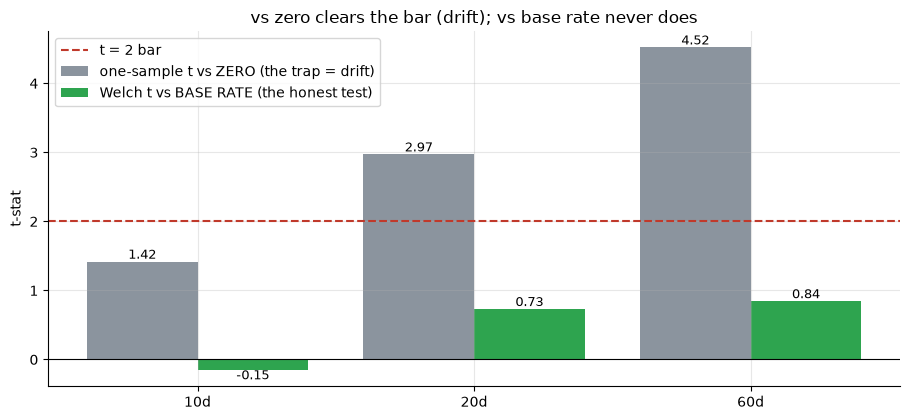

t vs zero: [1.42, 2.97, 4.52]
t vs base: [-0.15, 0.73, 0.84]


In [2]:
hs = [10,20,60]
if HAVE_REAL:
    t0, tb = [], []
    for h in hs:
        r = st.run_experiment(PANEL, base_len=R['base_len'], horizon=h, cost_bps=5.0, placebo=False)
        t0.append(r['t_zero']); tb.append(r['t_vs_base'])
else:
    t0=[R['h10'][7],R['h20'][7],R['h60'][7]]; tb=[R['h10'][9],R['h20'][9],R['h60'][9]]
x=np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.bar(x-.2,t0,.4,color=GREY,label='one-sample t vs ZERO (the trap = drift)')
ax.bar(x+.2,tb,.4,color=GREEN,label='Welch t vs BASE RATE (the honest test)')
ax.axhline(2,ls='--',c=RED,label='t = 2 bar'); ax.axhline(0,c='k',lw=.8)
for i,(a,b) in enumerate(zip(t0,tb)):
    ax.annotate(f'{a:.2f}',(i-.2,a),ha='center',va='bottom',fontsize=9)
    ax.annotate(f'{b:.2f}',(i+.2,b),ha='center',va='bottom' if b>=0 else 'top',fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('t-stat')
ax.set_title('vs zero clears the bar (drift); vs base rate never does'); ax.legend()
plt.tight_layout(); plt.show()
print('t vs zero:', [round(v,2) for v in t0]); print('t vs base:', [round(v,2) for v in tb])

> 💡 In plain words: against **zero**, the 20d and 60d breakouts clear the bar (t = 2.97, 4.52) — that's the equity drift premium talking. Against the **base rate** the same events sit at t = 0.73 / 0.84 — nowhere near 2. The shape contributes no measurable alpha.

### 4b · The date-shuffle placebo — is the *shape* doing anything?

Draw the same number of random entry dates per name (matching the breakout count) 5,000 times and pool the forward 20d returns. The observed breakout mean should sit deep in the right tail if the saucer matters. It doesn't.

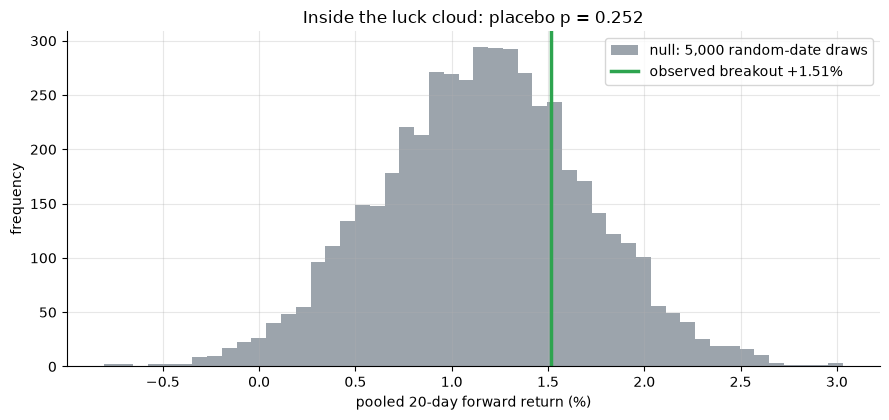

observed +1.51%  placebo p = 0.252  (random dates match the saucer ~25% of the time)


In [3]:
if HAVE_REAL:
    r = st.run_experiment(PANEL, base_len=R['base_len'], horizon=20, cost_bps=0.0, n_draws=5000, seed=416)
    counts = {tk: len(st.detect_breakouts(PANEL[tk], base_len=R['base_len'])) for tk in PANEL}
    pl = st.permutation_placebo(PANEL, R['base_len'], 20, counts, n_draws=5000, seed=416)
    draws = pl['draws']*100; draws = draws[np.isfinite(draws)]
    obs = r['gross_mean']*100; pval = r['p_placebo']
else:
    obs = R['h20'][2]; pval = R['h20'][10]
    rng = np.random.default_rng(416); draws = rng.normal(R['h20'][4], 0.35, 5000)
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: 5,000 random-date draws')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed breakout {obs:+.2f}%')
ax.set_xlabel('pooled 20-day forward return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {pval:.3f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  placebo p = {pval:.3f}  (random dates match the saucer ~{pval*100:.0f}% of the time)')

> 💡 In plain words: the green line sits **inside** the random-date cloud — random entries beat the saucer about **25%** of the time (p = 0.252). If the shape carried information, the observed return would be out in the tail. It isn't.

### 4c · Robustness — the verdict doesn't move with the knobs

Chart figures are subjective, so the fair worry is 'you drew it wrong.' We vary the saucer **window length** and the **fit threshold**. The breakout-vs-base *t* never clears 2 in any configuration — if anything the *tighter* definitions go *negative*.

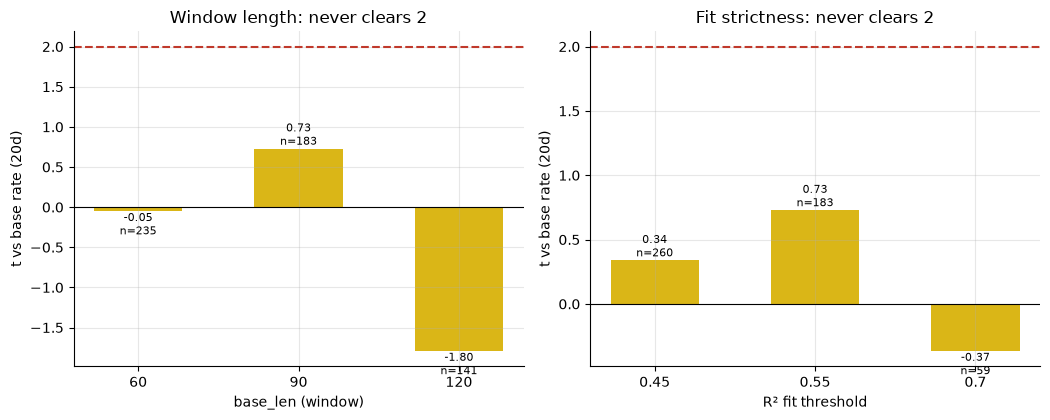

base_len: [(60, 235, -0.05), (90, 183, 0.73), (120, 141, -1.8)]
r2_min: [(0.45, 260, 0.34), (0.55, 183, 0.73), (0.7, 59, -0.37)]


In [4]:
if HAVE_REAL:
    rbl = []
    for bl in (60,90,120):
        r = st.run_experiment(PANEL, base_len=bl, horizon=20, cost_bps=5.0, placebo=False)
        rbl.append((bl, r['n_signals'], r['t_vs_base']))
    rr2 = []
    for r2 in (0.45,0.55,0.70):
        r = st.run_experiment(PANEL, base_len=90, horizon=20, r2_min=r2, cost_bps=5.0, placebo=False)
        rr2.append((r2, r['n_signals'], r['t_vs_base']))
else:
    rbl = [(b[0],b[1],b[4]) for b in R['rob_bl']]
    rr2 = [(b[0],b[1],b[4]) for b in R['rob_r2']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.3))
a1.bar([str(b[0]) for b in rbl],[b[2] for b in rbl],color=AMBER,width=.55)
a1.axhline(2,ls='--',c=RED); a1.axhline(0,c='k',lw=.8)
for i,b in enumerate(rbl): a1.annotate(f'{b[2]:.2f}\nn={b[1]}',(i,b[2]),ha='center',va='bottom' if b[2]>=0 else 'top',fontsize=8)
a1.set_xlabel('base_len (window)'); a1.set_ylabel('t vs base rate (20d)'); a1.set_title('Window length: never clears 2')
a2.bar([str(b[0]) for b in rr2],[b[2] for b in rr2],color=AMBER,width=.55)
a2.axhline(2,ls='--',c=RED); a2.axhline(0,c='k',lw=.8)
for i,b in enumerate(rr2): a2.annotate(f'{b[2]:.2f}\nn={b[1]}',(i,b[2]),ha='center',va='bottom' if b[2]>=0 else 'top',fontsize=8)
a2.set_xlabel('R\u00b2 fit threshold'); a2.set_ylabel('t vs base rate (20d)'); a2.set_title('Fit strictness: never clears 2')
plt.tight_layout(); plt.show()
print('base_len:', [(b[0],b[1],round(b[2],2)) for b in rbl]); print('r2_min:', [(b[0],b[1],round(b[2],2)) for b in rr2])

> 💡 In plain words: no knob rescues it. A *looser* saucer (more signals) still adds nothing; a *stricter*, prettier saucer (fewer signals) actually under-performs the base rate. There is no setting where 'buy the confirmed rounding-bottom breakout' beats random.

### 4d · Faithful-engine & power control — we know the truth here

On a synthetic panel we **plant the saucer shape**. With `edge=0` there is no post-breakout continuation (a true null: the figure fires, but must NOT beat the base rate). With `edge>0` we plant a real drift the detector must recover.

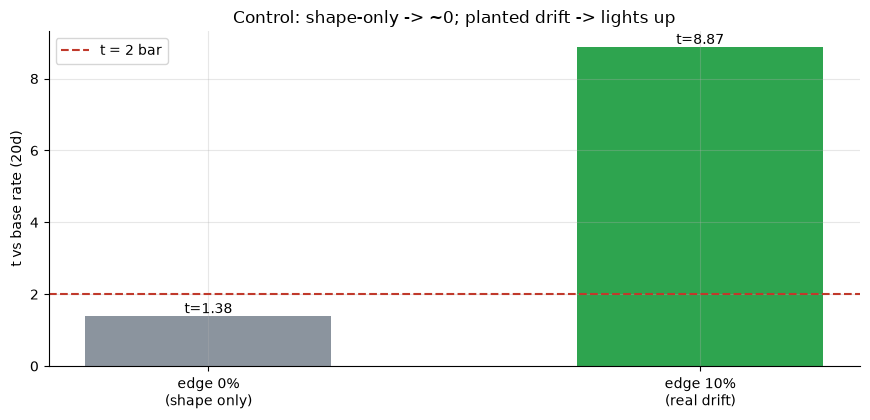

edge=+0.00: n=185 t_vs_base=1.38 p_placebo=0.111
edge=+0.10: n=186 t_vs_base=8.87 p_placebo=0.000


In [5]:
res = []
for edge in (0.0, 0.10):
    px,_ = data.synthetic_panel(edge=edge, seed=416)
    r = st.run_experiment(px, base_len=90, horizon=20, cost_bps=0.0, n_draws=2000, seed=416)
    res.append((edge, r['n_signals'], r['t_vs_base'], r['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8,4.3))
labels=[f'edge {e*100:.0f}%\n(shape only)' if e==0 else f'edge {e*100:.0f}%\n(real drift)' for e,_,_,_ in res]
tv=[r[2] for r in res]
ax.bar(labels,tv,color=[GREY,GREEN],width=.5)
ax.axhline(2,ls='--',c=RED,label='t = 2 bar')
for i,t in enumerate(tv): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('t vs base rate (20d)'); ax.set_title('Control: shape-only -> ~0; planted drift -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,t,p in res: print(f'edge={e:+.2f}: n={n} t_vs_base={t:.2f} p_placebo={p:.3f}')

> 💡 In plain words: when the shape carries **no** continuation the control sits at t = 1.38 (p = 0.111) — it does **not** fake an edge from a pretty shape. When a real drift is planted it jumps to t = 8.87 (p = 0.000). The engine can detect continuation when it exists — so the real-tape null is a real null, not a blind detector.

## 5 · The verdict

- **Signal `NONE`** — the confirmed-breakout forward return (**+1.51%** at 20d, **+4.07%** at 60d) **does not beat the base rate** (+1.14% / +3.31%): Welch t = 0.73 / 0.84, placebo p = 0.252 / 0.205. The one-sample t vs zero (t = 2.97) is the equity-drift trap, not a signal. Survivorship would only flatter a real effect — there is none.
- **Tradability `MIRAGE`** — no excess over being long to harvest; 5 bps of cost just turns an already-zero edge slightly negative. Nothing to size.
- **Accumulation signal? `NOT SUPPORTED`** — across base-window {60,90,120} and fit R\u00b2 {0.45,0.55,0.70} the breakout-vs-base t **never clears 2** (\u22121.80 to +0.73); the 'accumulation → markup regime change' leaves no measurable forward footprint.

## 6 · Could you trade it? — there is no excess to trade

The operational truth in one line: gross breakout return ≈ base rate, and net of costs it is *below* it. The 'tradeable' object — excess over just holding the stock — is indistinguishable from zero at every horizon, so capacity, impact and sizing are moot.

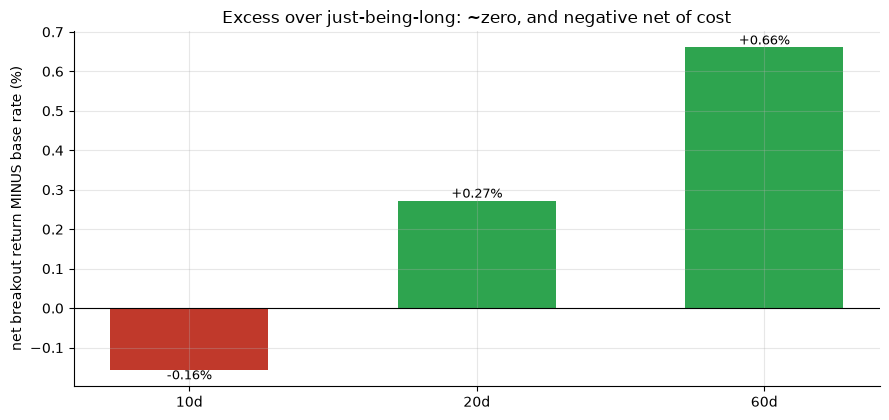

net excess over base by horizon: {'10d': -0.16, '20d': 0.27, '60d': 0.66}


In [6]:
hs=[10,20,60]
if HAVE_REAL:
    exc=[]
    for h in hs:
        r=st.run_experiment(PANEL, base_len=R['base_len'], horizon=h, cost_bps=5.0, placebo=False)
        exc.append((r['net_mean']-r['base_mean'])*100)
else:
    exc=[R['h10'][3]-R['h10'][4], R['h20'][3]-R['h20'][4], R['h60'][3]-R['h60'][4]]
fig,ax=plt.subplots(figsize=(9.0,4.3))
ax.bar([f'{h}d' for h in hs], exc, color=[GREEN if v>0 else RED for v in exc], width=.55)
ax.axhline(0,c='k',lw=.8)
for i,v in enumerate(exc): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
ax.set_ylabel('net breakout return MINUS base rate (%)'); ax.set_title('Excess over just-being-long: ~zero, and negative net of cost')
plt.tight_layout(); plt.show()
print('net excess over base by horizon:', {f'{h}d': round(v,2) for h,v in zip(hs,exc)})

> 💡 In plain words: the thing a trader would actually pocket — return *beyond* buy-and-hold — hovers around zero and dips negative after costs. A rounding bottom is a fine *after-the-fact description* of a base that already formed; it is not a forward edge.

## 7 · Going further

- **Volume-confirmed breakouts.** The strongest steelman adds rising volume; condition on a volume surge at the rim and re-run the base-rate test — a clean PR-able extension.
- **Detector geometry.** We used a parabola; alternatives (cubic-spline curvature, swing-pivot symmetry, neckline slope) are worth a sensitivity pass — but 4c suggests the geometry isn't the bottleneck.
- **The general lesson.** *Every* long-only chart pattern inherits the equity drift premium. Always benchmark a bullish figure against the base rate, never against zero — the sibling research-method demos make the same point about look-ahead and multiple testing.

*Reproducible core is offline & deterministic once cached. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*